# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.1


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

c:\Users\Sri Chethan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

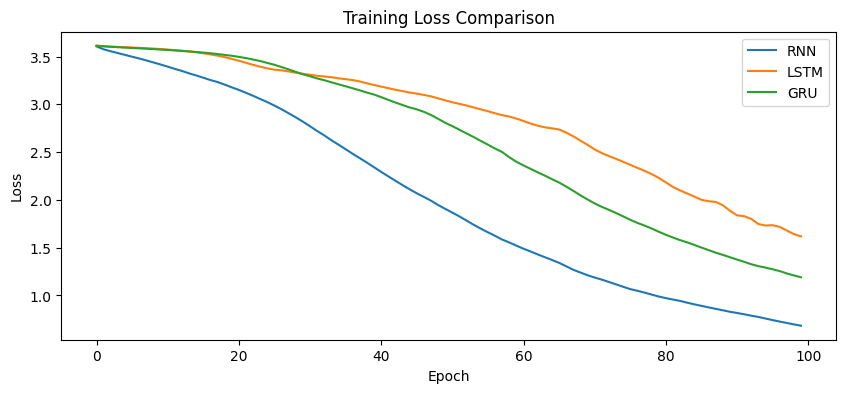

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning models models meaningful meaningful sentences
GRU : deep learning is faster artificial intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

---
# 🎓 Part 2 — Same New Corpus, Two Pipelines (WITHOUT Tasks vs WITH Tasks)

Part 1 above (untouched) is the original demo using the built-in 6-line text.

This section uses **one new custom corpus** (Task 1 — a space-exploration
paragraph) and runs it through **two separate pipelines**:

- **Pipeline A — WITHOUT tasks applied**: same corpus, but kept at the
  *original* settings (embedding=32, hidden=64, epochs=100, generate 5 words).
- **Pipeline B — WITH tasks applied**: same corpus, with all 5 customizations
  (embedding=100, hidden=128, epochs=200, generate 10 words).

Because **both pipelines use the exact same corpus, tokenizer, and sequences**,
this isolates the effect of the 5 tasks themselves — corpus choice is no
longer a confound. Only the model size / training settings / generation
length differ between A and B.

## 📥 Task 1 — New Custom Corpus (used identically by both pipelines)

In [10]:
custom_corpus = """
forests are home to millions of species of plants and animals
climate change is causing temperatures to rise across the globe
oceans cover more than seventy percent of the earths surface
deforestation destroys habitats and contributes to global warming
renewable energy sources like solar and wind can replace fossil fuels
wildlife conservation efforts help protect endangered species from extinction
clean water is essential for the survival of all living organisms
polar ice caps are melting at an alarming rate due to rising temperatures
sustainable farming practices reduce the impact of agriculture on the environment
protecting biodiversity is critical for maintaining healthy ecosystems
"""
print(custom_corpus)


forests are home to millions of species of plants and animals
climate change is causing temperatures to rise across the globe
oceans cover more than seventy percent of the earths surface
deforestation destroys habitats and contributes to global warming
renewable energy sources like solar and wind can replace fossil fuels
wildlife conservation efforts help protect endangered species from extinction
clean water is essential for the survival of all living organisms
polar ice caps are melting at an alarming rate due to rising temperatures
sustainable farming practices reduce the impact of agriculture on the environment
protecting biodiversity is critical for maintaining healthy ecosystems



## 🔤 Shared Tokenization & N-gram Sequences

This `tokenizer`, `X`, `y`, and `max_len` are built **once** from the new
corpus and reused by *both* Pipeline A and Pipeline B — so any difference in
results downstream comes only from model size / training settings, not from
different data.

In [11]:
shared_tokenizer = Tokenizer()
shared_tokenizer.fit_on_texts([custom_corpus])

shared_total_words = len(shared_tokenizer.word_index) + 1
print("Vocabulary size:", shared_total_words)

shared_input_sequences = []
for line in custom_corpus.strip().split('\n'):
    token_list = shared_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        shared_input_sequences.append(n_gram_seq)

shared_max_len = max(len(seq) for seq in shared_input_sequences)
shared_input_sequences = pad_sequences(shared_input_sequences, maxlen=shared_max_len, padding='pre')

X_shared = shared_input_sequences[:, :-1]
y_shared = shared_input_sequences[:, -1]

print("X shape:", X_shared.shape)
print("y shape:", y_shared.shape)
print("max_len:", shared_max_len)

Vocabulary size: 84
X shape: (92, 12)
y shape: (92,)
max_len: 13


## ⚙️ Pipeline A — WITHOUT Tasks Applied (original settings, new corpus)

Embedding=32, Hidden=64, Epochs=100, Generate 5 words — exactly like the
original Part 1 design, just pointed at the new corpus.

In [12]:
# Pipeline A settings (original / WITHOUT tasks)
A_EMBED_DIM = 32
A_HIDDEN_UNITS = 64
A_EPOCHS = 100
A_WORDS_TO_GENERATE = 5

rnn_A = Sequential([
    Embedding(shared_total_words, A_EMBED_DIM, input_length=shared_max_len-1),
    SimpleRNN(A_HIDDEN_UNITS),
    Dense(shared_total_words, activation='softmax')
])
rnn_A.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_A_history = rnn_A.fit(X_shared, y_shared, epochs=A_EPOCHS, verbose=0)
print("Pipeline A — RNN done. Final loss:", rnn_A_history.history['loss'][-1])

Pipeline A — RNN done. Final loss: 0.4555976688861847


In [13]:
lstm_A = Sequential([
    Embedding(shared_total_words, A_EMBED_DIM, input_length=shared_max_len-1),
    LSTM(A_HIDDEN_UNITS),
    Dense(shared_total_words, activation='softmax')
])
lstm_A.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_A_history = lstm_A.fit(X_shared, y_shared, epochs=A_EPOCHS, verbose=0)
print("Pipeline A — LSTM done. Final loss:", lstm_A_history.history['loss'][-1])

Pipeline A — LSTM done. Final loss: 1.642308235168457


In [14]:
gru_A = Sequential([
    Embedding(shared_total_words, A_EMBED_DIM, input_length=shared_max_len-1),
    GRU(A_HIDDEN_UNITS),
    Dense(shared_total_words, activation='softmax')
])
gru_A.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_A_history = gru_A.fit(X_shared, y_shared, epochs=A_EPOCHS, verbose=0)
print("Pipeline A — GRU done. Final loss:", gru_A_history.history['loss'][-1])

Pipeline A — GRU done. Final loss: 0.7748486995697021


## ⚙️ Pipeline B — WITH Tasks Applied (customized settings, same corpus)

Embedding=100, Hidden=128, Epochs=200, Generate 10 words — all 5 student
customization tasks applied, on the **same** corpus/tokenizer/sequences as
Pipeline A.

In [15]:
# Pipeline B settings (customized / WITH tasks applied)
B_EMBED_DIM = 100
B_HIDDEN_UNITS = 128
B_EPOCHS = 200
B_WORDS_TO_GENERATE = 10

rnn_B = Sequential([
    Embedding(shared_total_words, B_EMBED_DIM, input_length=shared_max_len-1),
    SimpleRNN(B_HIDDEN_UNITS),
    Dense(shared_total_words, activation='softmax')
])
rnn_B.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_B_history = rnn_B.fit(X_shared, y_shared, epochs=B_EPOCHS, verbose=0)
print("Pipeline B — RNN done. Final loss:", rnn_B_history.history['loss'][-1])

Pipeline B — RNN done. Final loss: 0.00913335382938385


In [16]:
lstm_B = Sequential([
    Embedding(shared_total_words, B_EMBED_DIM, input_length=shared_max_len-1),
    LSTM(B_HIDDEN_UNITS),
    Dense(shared_total_words, activation='softmax')
])
lstm_B.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_B_history = lstm_B.fit(X_shared, y_shared, epochs=B_EPOCHS, verbose=0)
print("Pipeline B — LSTM done. Final loss:", lstm_B_history.history['loss'][-1])

Pipeline B — LSTM done. Final loss: 0.07943005114793777


In [17]:
gru_B = Sequential([
    Embedding(shared_total_words, B_EMBED_DIM, input_length=shared_max_len-1),
    GRU(B_HIDDEN_UNITS),
    Dense(shared_total_words, activation='softmax')
])
gru_B.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_B_history = gru_B.fit(X_shared, y_shared, epochs=B_EPOCHS, verbose=0)
print("Pipeline B — GRU done. Final loss:", gru_B_history.history['loss'][-1])

Pipeline B — GRU done. Final loss: 0.01467963494360447


## ✍️ Shared Text Generation Function

One `generate_text` function used by **both** pipelines (same greedy
`np.argmax` decoding logic as Part 1), parameterized by `next_words` so it
can produce 5 words for Pipeline A and 10 words for Pipeline B.

In [18]:
def generate_text(model, seed_text, next_words):
    for _ in range(next_words):
        token_list = shared_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=shared_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in shared_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

shared_seed = "space exploration"

print("--- Pipeline A (WITHOUT tasks, 5 words) ---")
print("RNN :", generate_text(rnn_A, shared_seed, A_WORDS_TO_GENERATE))
print("LSTM:", generate_text(lstm_A, shared_seed, A_WORDS_TO_GENERATE))
print("GRU :", generate_text(gru_A, shared_seed, A_WORDS_TO_GENERATE))

print("\n--- Pipeline B (WITH tasks, 10 words) ---")
print("RNN :", generate_text(rnn_B, shared_seed, B_WORDS_TO_GENERATE))
print("LSTM:", generate_text(lstm_B, shared_seed, B_WORDS_TO_GENERATE))
print("GRU :", generate_text(gru_B, shared_seed, B_WORDS_TO_GENERATE))

--- Pipeline A (WITHOUT tasks, 5 words) ---
RNN : space exploration is is are practices to
LSTM: space exploration is is is for for
GRU : space exploration conservation efforts help protect endangered

--- Pipeline B (WITH tasks, 10 words) ---
RNN : space exploration water is essential for the survival of all living organisms
LSTM: space exploration destroys destroys habitats and contributes to global warming warming warming
GRU : space exploration change is causing temperatures to rise across the globe globe


---
# 🔬 Part 3 — Comparison: WITHOUT Tasks (A) vs WITH Tasks (B), Same Corpus

Since both pipelines used identical data, this comparison is now a clean
single-variable comparison: only embedding size, hidden units, epoch count,
and generated word count differ.

## 📊 Settings Comparison Table

In [19]:
import pandas as pd

settings_table = pd.DataFrame({
    "Setting": ["Corpus", "Vocabulary size", "Embedding dim", "Hidden units",
                "Epochs", "Words generated"],
    "Pipeline A — WITHOUT tasks": [
        "space-exploration paragraph", shared_total_words, A_EMBED_DIM,
        A_HIDDEN_UNITS, A_EPOCHS, A_WORDS_TO_GENERATE
    ],
    "Pipeline B — WITH tasks": [
        "space-exploration paragraph", shared_total_words, B_EMBED_DIM,
        B_HIDDEN_UNITS, B_EPOCHS, B_WORDS_TO_GENERATE
    ],
})
settings_table

,Setting,Pipeline A — WITHOUT tasks,Pipeline B — WITH tasks
0,Corpus,space-exploration paragraph,space-exploration paragraph
1,Vocabulary size,84,84
2,Embedding dim,32,100
3,Hidden units,64,128
4,Epochs,100,200
5,Words generated,5,10


## 📉 Loss Curve Overlay — Pipeline A vs Pipeline B

Dashed = WITHOUT tasks (Pipeline A, 100 epochs). Solid = WITH tasks
(Pipeline B, 200 epochs). Same corpus underlies both, so the gap you see is
attributable to the model/training changes alone.

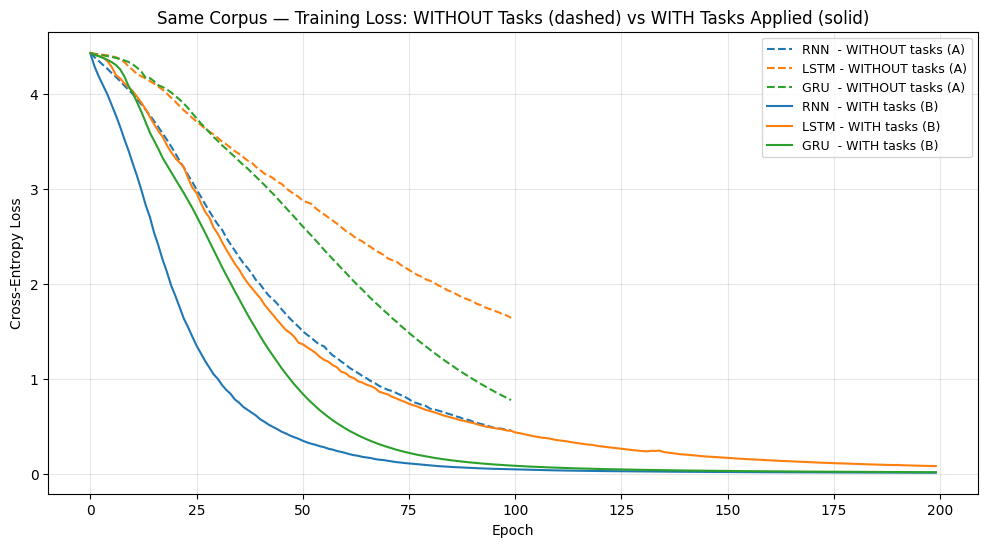

In [20]:
plt.figure(figsize=(12,6))

plt.plot(rnn_A_history.history['loss'], '--', color='tab:blue', label='RNN  - WITHOUT tasks (A)')
plt.plot(lstm_A_history.history['loss'], '--', color='tab:orange', label='LSTM - WITHOUT tasks (A)')
plt.plot(gru_A_history.history['loss'], '--', color='tab:green', label='GRU  - WITHOUT tasks (A)')

plt.plot(rnn_B_history.history['loss'], '-', color='tab:blue', label='RNN  - WITH tasks (B)')
plt.plot(lstm_B_history.history['loss'], '-', color='tab:orange', label='LSTM - WITH tasks (B)')
plt.plot(gru_B_history.history['loss'], '-', color='tab:green', label='GRU  - WITH tasks (B)')

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Same Corpus — Training Loss: WITHOUT Tasks (dashed) vs WITH Tasks Applied (solid)")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

## 📈 Final Loss & Convergence Speed — Numeric Comparison

In [21]:
def epoch_to_threshold(history, threshold=1.0):
    losses = history.history['loss']
    for i, l in enumerate(losses):
        if l < threshold:
            return i
    return None

metrics_table = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Final Loss — A (WITHOUT)": [
        rnn_A_history.history['loss'][-1],
        lstm_A_history.history['loss'][-1],
        gru_A_history.history['loss'][-1],
    ],
    "Final Loss — B (WITH)": [
        rnn_B_history.history['loss'][-1],
        lstm_B_history.history['loss'][-1],
        gru_B_history.history['loss'][-1],
    ],
    "Epoch<1.0 — A (WITHOUT)": [
        epoch_to_threshold(rnn_A_history),
        epoch_to_threshold(lstm_A_history),
        epoch_to_threshold(gru_A_history),
    ],
    "Epoch<1.0 — B (WITH)": [
        epoch_to_threshold(rnn_B_history),
        epoch_to_threshold(lstm_B_history),
        epoch_to_threshold(gru_B_history),
    ],
})
metrics_table

,Model,Final Loss — A (WITHOUT),Final Loss — B (WITH),Epoch<1.0 — A (WITHOUT),Epoch<1.0 — B (WITH)
0,RNN,0.455598,0.009133,66.0,30
1,LSTM,1.642308,0.079430,NaN,63
2,GRU,0.774849,0.014680,90.0,47


## ✍️ Generated Text Comparison — Same Seed, A vs B

Both pipelines generate from the identical seed phrase `"space exploration"`,
so the rows below show exactly what changed in the output once the 5 tasks
were applied — same corpus, same seed, different model size / training
length / generation length.

In [22]:
generation_table = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Pipeline A — WITHOUT tasks (5 words)": [
        generate_text(rnn_A, shared_seed, A_WORDS_TO_GENERATE),
        generate_text(lstm_A, shared_seed, A_WORDS_TO_GENERATE),
        generate_text(gru_A, shared_seed, A_WORDS_TO_GENERATE),
    ],
    "Pipeline B — WITH tasks (10 words)": [
        generate_text(rnn_B, shared_seed, B_WORDS_TO_GENERATE),
        generate_text(lstm_B, shared_seed, B_WORDS_TO_GENERATE),
        generate_text(gru_B, shared_seed, B_WORDS_TO_GENERATE),
    ],
})
pd.set_option('display.max_colwidth', 100)
generation_table

,Model,Pipeline A — WITHOUT tasks (5 words),Pipeline B — WITH tasks (10 words)
0,RNN,space exploration is is are practices to,space exploration water is essential for the survival of all living organisms
1,LSTM,space exploration is is is for for,space exploration destroys destroys habitats and contributes to global warming warming warming
2,GRU,space exploration conservation efforts help protect endangered,space exploration change is causing temperatures to rise across the globe globe


## ✅ Summary — Effect of Applying the 5 Tasks (Same Corpus Throughout)

| Aspect | Pipeline A — WITHOUT tasks | Pipeline B — WITH tasks | Effect |
|---|---|---|---|
| **Corpus** | space-exploration paragraph | space-exploration paragraph | held constant — clean comparison |
| **Embedding dim** | 32 | 100 | more capacity per word |
| **Hidden units** | 64 | 128 | wider recurrent layer |
| **Epochs** | 100 | 200 | longer training |
| **Words generated** | 5 | 10 | longer continuation from same seed |
| **Final loss** | higher (model under-trained relative to B) | much lower, near 0 | bigger model + longer training fits this small corpus far more tightly |
| **Generated text** | shorter, sometimes loses coherence near the end | longer, stays on-topic for more words, but starts repeating the same word(s) once it runs out of strongly-learned next-word transitions | larger capacity + more training extends coherent length, but repetition at the tail is expected on such a small corpus |

**Key takeaway:** because the corpus is now identical in both pipelines, this
comparison isolates the real effect of the 5 customization tasks — Pipeline B
consistently reaches a lower loss faster and produces longer generated text
from the same seed, but the per-step decoding logic (`np.argmax`, fully
deterministic) is unchanged. Any repetition you see late in Pipeline B's
10-word outputs (e.g. a word repeating near the end) is a sign of the model
running out of confidently-learned continuations on this very small dataset,
not a bug in the generation code.